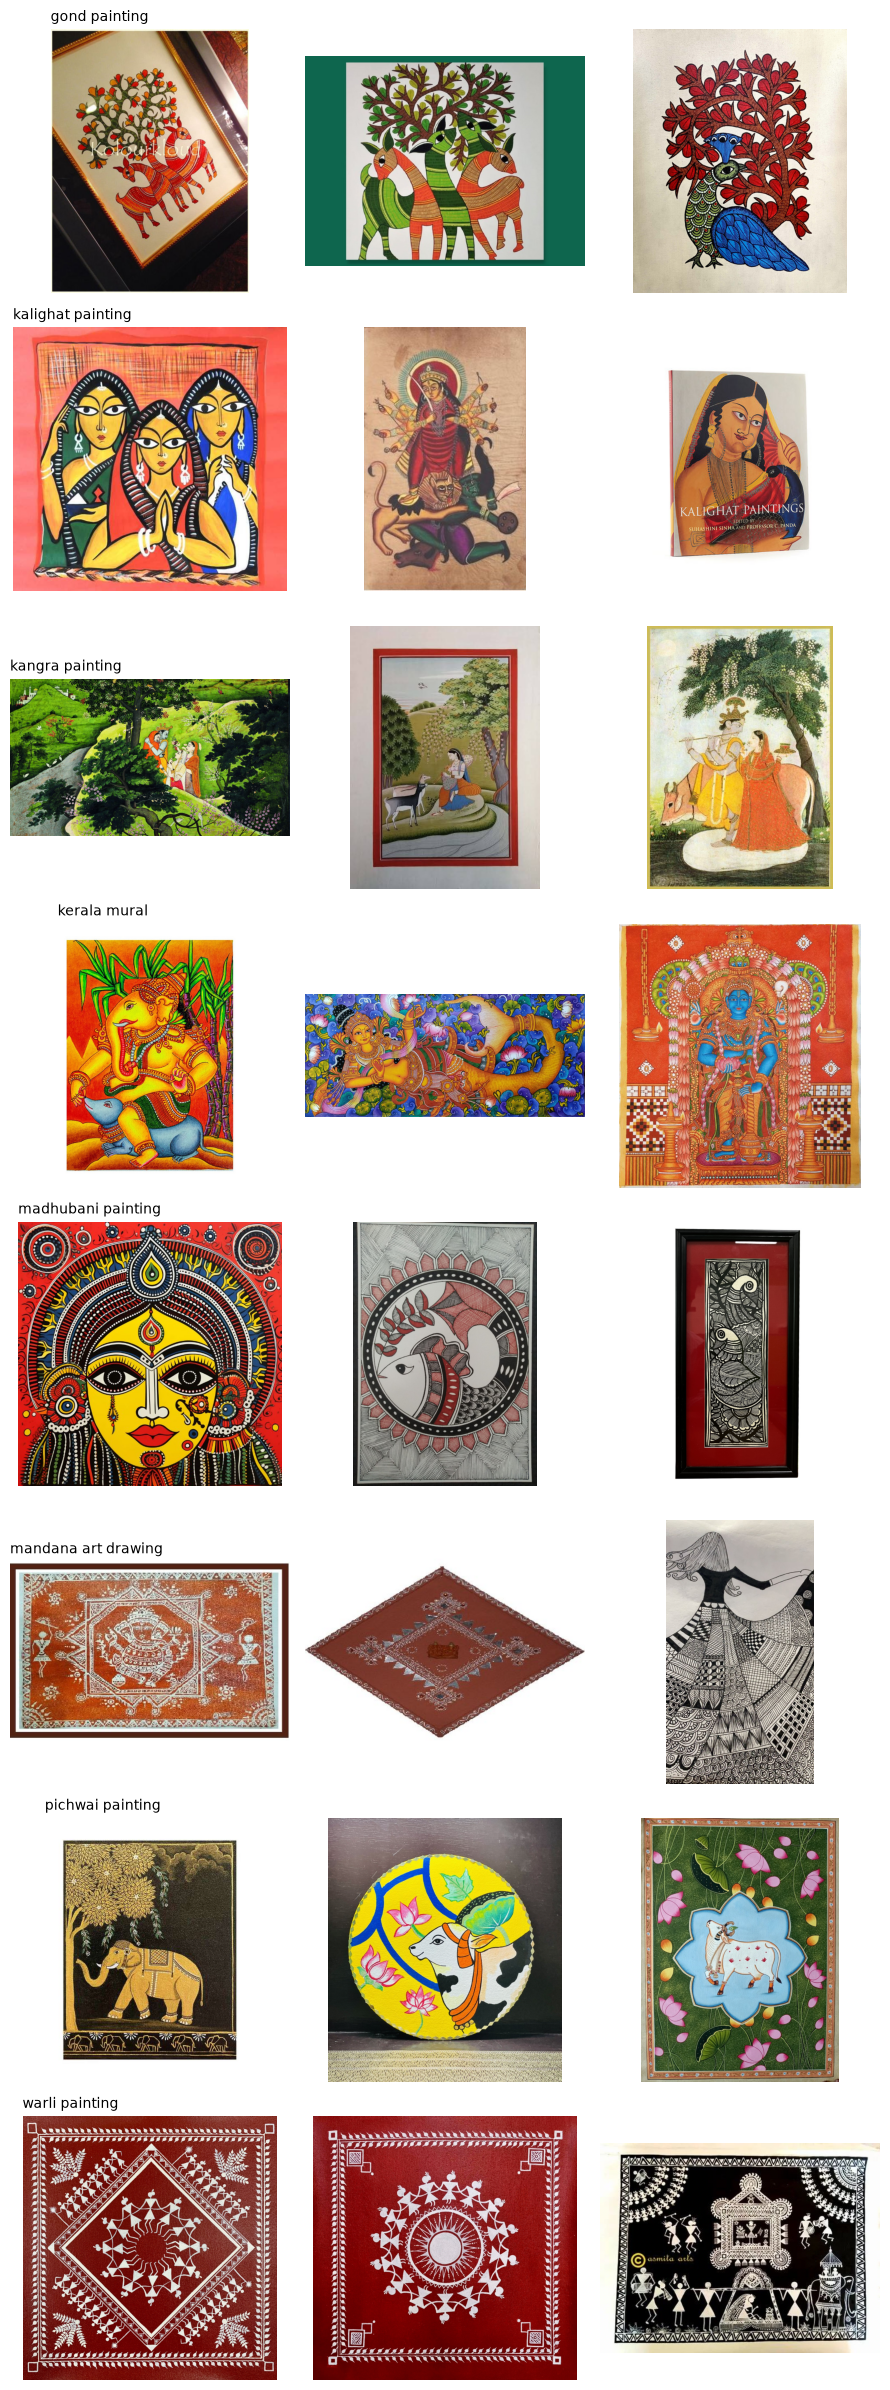

In [4]:
import os
import matplotlib.pyplot as plt
from PIL import Image

data_dir = "raw"
styles = [f for f in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, f))]
valid_ext = (".jpg", ".jpeg", ".png", ".webp")

fig, axes = plt.subplots(len(styles), 3, figsize=(9, 3 * len(styles)))

for i, style in enumerate(styles):
    style_path = os.path.join(data_dir, style)
    images = [f for f in os.listdir(style_path) if f.lower().endswith(valid_ext)][:3]
    for j, img_name in enumerate(images):
        img_path = os.path.join(style_path, img_name)
        img = Image.open(img_path)
        axes[i, j].imshow(img)
        axes[i, j].axis("off")
        if j == 0:
            axes[i, j].set_title(style, fontsize=10, loc="left")

plt.tight_layout()
plt.show()

In [2]:
import os
print(os.getcwd())

D:\folk-art-ai\data


In [5]:
import os
from PIL import Image

data_dir = "raw"
valid_ext = (".jpg", ".jpeg", ".png", ".webp")

junk_files = []
corrupt_files = []

for style in os.listdir(data_dir):
    style_path = os.path.join(data_dir, style)
    if not os.path.isdir(style_path):
        continue
    for fname in os.listdir(style_path):
        fpath = os.path.join(style_path, fname)
        if not fname.lower().endswith(valid_ext):
            junk_files.append(fpath)
            continue
        try:
            img = Image.open(fpath)
            img.verify()
        except Exception:
            corrupt_files.append(fpath)

print("Non-image junk files found:", len(junk_files))
for f in junk_files:
    print(" -", f)

print("\nCorrupt image files found:", len(corrupt_files))
for f in corrupt_files:
    print(" -", f)

Non-image junk files found: 14
 - raw\gond painting\gond72.gif
 - raw\gond painting\gond73.gif
 - raw\gond painting\pageInfo.txt
 - raw\kalighat painting\kalighat52.gif
 - raw\kalighat painting\pageInfo.txt
 - raw\kalighat painting\Premature-Worship-of-the-Goddess-Kalighat-Painting-dated-1885-Victoria-and-Albert.ppm
 - raw\kalighat painting\Rama-Worships-the-Goddess-Kalighat-Painting-dated-1885-Victoria-and-Albert-Museum.ppm
 - raw\kangra painting\FZ7QSdrVUAEM5M4.jpg_large
 - raw\kangra painting\pageInfo.txt
 - raw\kerala mural\pageInfo.txt
 - raw\madhubani painting\pageInfo.txt
 - raw\mandana art drawing\pageInfo.txt
 - raw\pichwai painting\pageInfo.txt
 - raw\warli painting\pageInfo.txt

Corrupt image files found: 0


In [6]:
import os

junk_files = [
    "raw\\gond painting\\gond72.gif",
    "raw\\gond painting\\gond73.gif",
    "raw\\gond painting\\pageInfo.txt",
    "raw\\kalighat painting\\kalighat52.gif",
    "raw\\kalighat painting\\pageInfo.txt",
    "raw\\kalighat painting\\Premature-Worship-of-the-Goddess-Kalighat-Painting-dated-1885-Victoria-and-Albert.ppm",
    "raw\\kalighat painting\\Rama-Worships-the-Goddess-Kalighat-Painting-dated-1885-Victoria-and-Albert-Museum.ppm",
    "raw\\kangra painting\\FZ7QSdrVUAEM5M4.jpg_large",
    "raw\\kangra painting\\pageInfo.txt",
    "raw\\kerala mural\\pageInfo.txt",
    "raw\\madhubani painting\\pageInfo.txt",
    "raw\\mandana art drawing\\pageInfo.txt",
    "raw\\pichwai painting\\pageInfo.txt",
    "raw\\warli painting\\pageInfo.txt",
]

removed = 0
for f in junk_files:
    if os.path.exists(f):
        os.remove(f)
        removed += 1

print(f"Removed {removed} junk files.")

Removed 14 junk files.


In [7]:
import os
import shutil
import random

random.seed(42)

src_dir = "raw"
dst_dir = "processed/style"

splits = {"train": 0.70, "val": 0.15, "test": 0.15}

for style in os.listdir(src_dir):
    style_path = os.path.join(src_dir, style)
    if not os.path.isdir(style_path):
        continue

    clean_name = style.replace(" painting", "").replace(" drawing", "").replace(" ", "_").lower()

    images = [f for f in os.listdir(style_path) if f.lower().endswith((".jpg", ".jpeg", ".png", ".webp"))]
    random.shuffle(images)

    n = len(images)
    n_train = int(n * splits["train"])
    n_val = int(n * splits["val"])

    split_files = {
        "train": images[:n_train],
        "val": images[n_train:n_train + n_val],
        "test": images[n_train + n_val:],
    }

    for split, files in split_files.items():
        out_dir = os.path.join(dst_dir, split, clean_name)
        os.makedirs(out_dir, exist_ok=True)
        for fname in files:
            shutil.copy(os.path.join(style_path, fname), os.path.join(out_dir, fname))

    print(f"{clean_name}: {n} total -> train {len(split_files['train'])}, val {len(split_files['val'])}, test {len(split_files['test'])}")

gond: 98 total -> train 68, val 14, test 16
kalighat: 244 total -> train 170, val 36, test 38
kangra: 87 total -> train 60, val 13, test 14
kerala_mural: 94 total -> train 65, val 14, test 15
madhubani: 95 total -> train 66, val 14, test 15
mandana_art: 140 total -> train 98, val 21, test 21
pichwai: 96 total -> train 67, val 14, test 15
warli: 97 total -> train 67, val 14, test 16


In [8]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Data transforms — resize, augment training data, normalize for ResNet
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

train_data = datasets.ImageFolder("processed/style/train", transform=train_transform)
val_data = datasets.ImageFolder("processed/style/val", transform=val_transform)

train_loader = DataLoader(train_data, batch_size=16, shuffle=True)
val_loader = DataLoader(val_data, batch_size=16, shuffle=False)

print("Classes:", train_data.classes)
print("Train images:", len(train_data), "| Val images:", len(val_data))

Using device: cpu
Classes: ['gond', 'kalighat', 'kangra', 'kerala_mural', 'madhubani', 'mandana_art', 'pichwai', 'warli']
Train images: 661 | Val images: 140


In [9]:
from torchvision.models import resnet18, ResNet18_Weights

# Load pretrained ResNet18
model = resnet18(weights=ResNet18_Weights.DEFAULT)

# Freeze all layers first (we only train the final layer initially)
for param in model.parameters():
    param.requires_grad = False

# Replace the final layer to match our 8 classes
num_classes = len(train_data.classes)
model.fc = nn.Linear(model.fc.in_features, num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.fc.parameters(), lr=0.001)

print(model.fc)
print("Model ready. Training only the final layer for now.")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\Admin/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:19<00:00, 2.36MB/s]

Linear(in_features=512, out_features=8, bias=True)
Model ready. Training only the final layer for now.


In [10]:
import time

num_epochs = 10

for epoch in range(num_epochs):
    start = time.time()

    # --- Training ---
    model.train()
    train_loss, train_correct = 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        train_correct += (outputs.argmax(1) == labels).sum().item()

    train_loss /= len(train_data)
    train_acc = train_correct / len(train_data)

    # --- Validation ---
    model.eval()
    val_loss, val_correct = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            val_correct += (outputs.argmax(1) == labels).sum().item()

    val_loss /= len(val_data)
    val_acc = val_correct / len(val_data)

    elapsed = time.time() - start
    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {train_loss:.3f}, Train Acc: {train_acc:.2%} | "
          f"Val Loss: {val_loss:.3f}, Val Acc: {val_acc:.2%} | "
          f"Time: {elapsed:.1f}s")

D:\folk-art-ai\venv\Lib\site-packages\PIL\Image.py:1136: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 1/10 | Train Loss: 1.880, Train Acc: 32.07% | Val Loss: 1.508, Val Acc: 45.00% | Time: 57.1s
Epoch 2/10 | Train Loss: 1.376, Train Acc: 52.65% | Val Loss: 1.178, Val Acc: 56.43% | Time: 46.4s
Epoch 3/10 | Train Loss: 1.120, Train Acc: 63.39% | Val Loss: 0.945, Val Acc: 72.86% | Time: 47.3s
Epoch 4/10 | Train Loss: 0.996, Train Acc: 68.08% | Val Loss: 0.877, Val Acc: 75.71% | Time: 49.7s
Epoch 5/10 | Train Loss: 0.849, Train Acc: 73.98% | Val Loss: 0.766, Val Acc: 74.29% | Time: 50.2s
Epoch 6/10 | Train Loss: 0.781, Train Acc: 77.16% | Val Loss: 0.744, Val Acc: 79.29% | Time: 52.2s
Epoch 7/10 | Train Loss: 0.711, Train Acc: 76.85% | Val Loss: 0.699, Val Acc: 77.86% | Time: 55.2s
Epoch 8/10 | Train Loss: 0.717, Train Acc: 79.88% | Val Loss: 0.691, Val Acc: 77.86% | Time: 54.1s
Epoch 9/10 | Train Loss: 0.700, Train Acc: 76.85% | Val Loss: 0.717, Val Acc: 78.57% | Time: 53.8s
Epoch 10/10 | Train Loss: 0.635, Train Acc: 79.58% | Val Loss: 0.655, Val Acc: 80.71% | Time: 54.4s


In [11]:
import os

os.makedirs("../models", exist_ok=True)
torch.save(model.state_dict(), "../models/style_classifier_v1.pth")
print("Model saved to models/style_classifier_v1.pth")

Model saved to models/style_classifier_v1.pth


In [12]:
# Unfreeze the last two ResNet blocks (layer3 and layer4) for fine-tuning
for name, param in model.named_parameters():
    if "layer3" in name or "layer4" in name or "fc" in name:
        param.requires_grad = True

# Lower learning rate since we're now touching pretrained weights — don't want to wreck them
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()), lr=0.0001
)

num_epochs = 8

for epoch in range(num_epochs):
    start = time.time()

    model.train()
    train_loss, train_correct = 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * images.size(0)
        train_correct += (outputs.argmax(1) == labels).sum().item()

    train_loss /= len(train_data)
    train_acc = train_correct / len(train_data)

    model.eval()
    val_loss, val_correct = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            val_correct += (outputs.argmax(1) == labels).sum().item()

    val_loss /= len(val_data)
    val_acc = val_correct / len(val_data)

    elapsed = time.time() - start
    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {train_loss:.3f}, Train Acc: {train_acc:.2%} | "
          f"Val Loss: {val_loss:.3f}, Val Acc: {val_acc:.2%} | "
          f"Time: {elapsed:.1f}s")

Epoch 1/8 | Train Loss: 0.581, Train Acc: 82.00% | Val Loss: 0.469, Val Acc: 85.00% | Time: 74.9s
Epoch 2/8 | Train Loss: 0.196, Train Acc: 94.10% | Val Loss: 0.364, Val Acc: 88.57% | Time: 75.5s
Epoch 3/8 | Train Loss: 0.125, Train Acc: 97.28% | Val Loss: 0.338, Val Acc: 90.00% | Time: 75.3s
Epoch 4/8 | Train Loss: 0.104, Train Acc: 96.52% | Val Loss: 0.378, Val Acc: 89.29% | Time: 75.6s
Epoch 5/8 | Train Loss: 0.069, Train Acc: 98.34% | Val Loss: 0.418, Val Acc: 88.57% | Time: 76.6s
Epoch 6/8 | Train Loss: 0.053, Train Acc: 99.24% | Val Loss: 0.424, Val Acc: 90.00% | Time: 76.3s
Epoch 7/8 | Train Loss: 0.051, Train Acc: 99.09% | Val Loss: 0.431, Val Acc: 90.00% | Time: 75.7s
Epoch 8/8 | Train Loss: 0.039, Train Acc: 99.24% | Val Loss: 0.403, Val Acc: 90.00% | Time: 75.8s


In [13]:
torch.save(model.state_dict(), "../models/style_classifier_v2.pth")
print("Improved model saved to models/style_classifier_v2.pth")

# Save class names too — we'll need this order later for predictions
import json
with open("../models/style_classes.json", "w") as f:
    json.dump(train_data.classes, f)
print("Class list saved.")

Improved model saved to models/style_classifier_v2.pth
Class list saved.


In [14]:
import os
import cv2
import numpy as np
from PIL import Image, ImageFilter, ImageEnhance
import random

random.seed(42)

def make_replica(img_path, out_path):
    img = Image.open(img_path).convert("RGB")

    # 1. Slight blur (printing loses fine brush texture)
    img = img.filter(ImageFilter.GaussianBlur(radius=random.uniform(0.8, 1.5)))

    # 2. Reduce color richness slightly (print colors are flatter than hand-mixed paint)
    enhancer = ImageEnhance.Color(img)
    img = enhancer.enhance(random.uniform(0.75, 0.9))

    # 3. Add halftone-like dot pattern (simulates print dots)
    arr = np.array(img)
    noise = np.random.randint(-8, 8, arr.shape, dtype=np.int16)
    arr = np.clip(arr.astype(np.int16) + noise, 0, 255).astype(np.uint8)
    img = Image.fromarray(arr)

    # 4. Slight sharpness reduction (printed reproductions lose crispness)
    enhancer2 = ImageEnhance.Sharpness(img)
    img = enhancer2.enhance(random.uniform(0.6, 0.8))

    img.save(out_path, quality=90)

src_dir = "processed/style/train"
dst_genuine = "processed/authenticity/genuine"
dst_replica = "processed/authenticity/replica"

os.makedirs(dst_genuine, exist_ok=True)
os.makedirs(dst_replica, exist_ok=True)

count = 0
for style in os.listdir(src_dir):
    style_path = os.path.join(src_dir, style)
    for fname in os.listdir(style_path):
        src_path = os.path.join(style_path, fname)

        # Save genuine copy
        genuine_out = os.path.join(dst_genuine, f"{style}_{fname}")
        Image.open(src_path).convert("RGB").save(genuine_out, quality=95)

        # Create and save replica version
        replica_out = os.path.join(dst_replica, f"{style}_{fname}")
        make_replica(src_path, replica_out)

        count += 1

print(f"Done. Created {count} genuine + {count} replica images.")

Done. Created 661 genuine + 661 replica images.


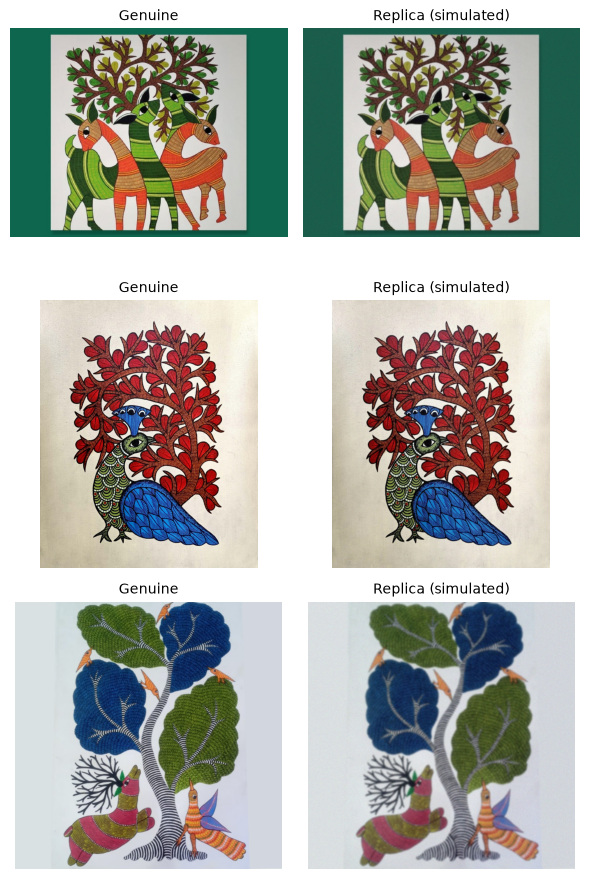

In [15]:
import matplotlib.pyplot as plt
from PIL import Image
import os

genuine_dir = "processed/authenticity/genuine"
replica_dir = "processed/authenticity/replica"

sample_files = os.listdir(genuine_dir)[:3]

fig, axes = plt.subplots(3, 2, figsize=(6, 9))
for i, fname in enumerate(sample_files):
    g_img = Image.open(os.path.join(genuine_dir, fname))
    r_img = Image.open(os.path.join(replica_dir, fname))

    axes[i, 0].imshow(g_img)
    axes[i, 0].set_title("Genuine", fontsize=10)
    axes[i, 0].axis("off")

    axes[i, 1].imshow(r_img)
    axes[i, 1].set_title("Replica (simulated)", fontsize=10)
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

In [16]:
import os
import shutil
import random

random.seed(42)

def split_and_copy(src_dir, label, dst_base):
    files = os.listdir(src_dir)
    random.shuffle(files)
    n = len(files)
    n_train = int(n * 0.8)

    for i, fname in enumerate(files):
        split = "train" if i < n_train else "val"
        out_dir = os.path.join(dst_base, split, label)
        os.makedirs(out_dir, exist_ok=True)
        shutil.copy(os.path.join(src_dir, fname), os.path.join(out_dir, fname))

dst_base = "processed/authenticity_split"

split_and_copy("processed/authenticity/genuine", "genuine", dst_base)
split_and_copy("processed/authenticity/replica", "replica", dst_base)

print("Split complete.")
for split in ["train", "val"]:
    for label in ["genuine", "replica"]:
        path = os.path.join(dst_base, split, label)
        print(f"{split}/{label}: {len(os.listdir(path))} images")

Split complete.
train/genuine: 528 images
train/replica: 528 images
val/genuine: 133 images
val/replica: 133 images


In [17]:
from torchvision.models import resnet18, ResNet18_Weights

# Data loaders (reuse same transforms as before)
auth_train_data = datasets.ImageFolder("processed/authenticity_split/train", transform=train_transform)
auth_val_data = datasets.ImageFolder("processed/authenticity_split/val", transform=val_transform)

auth_train_loader = DataLoader(auth_train_data, batch_size=16, shuffle=True)
auth_val_loader = DataLoader(auth_val_data, batch_size=16, shuffle=False)

print("Classes:", auth_train_data.classes)
print("Train images:", len(auth_train_data), "| Val images:", len(auth_val_data))

# New model for authenticity (2 classes: genuine, replica)
auth_model = resnet18(weights=ResNet18_Weights.DEFAULT)

for param in auth_model.parameters():
    param.requires_grad = False

auth_model.fc = nn.Linear(auth_model.fc.in_features, 2)
auth_model = auth_model.to(device)

auth_criterion = nn.CrossEntropyLoss()
auth_optimizer = torch.optim.Adam(auth_model.fc.parameters(), lr=0.001)

print("Authenticity model ready.")

Classes: ['genuine', 'replica']
Train images: 1056 | Val images: 266
Authenticity model ready.


In [18]:
num_epochs = 8

for epoch in range(num_epochs):
    start = time.time()

    auth_model.train()
    train_loss, train_correct = 0, 0
    for images, labels in auth_train_loader:
        images, labels = images.to(device), labels.to(device)

        auth_optimizer.zero_grad()
        outputs = auth_model(images)
        loss = auth_criterion(outputs, labels)
        loss.backward()
        auth_optimizer.step()

        train_loss += loss.item() * images.size(0)
        train_correct += (outputs.argmax(1) == labels).sum().item()

    train_loss /= len(auth_train_data)
    train_acc = train_correct / len(auth_train_data)

    auth_model.eval()
    val_loss, val_correct = 0, 0
    with torch.no_grad():
        for images, labels in auth_val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = auth_model(images)
            loss = auth_criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            val_correct += (outputs.argmax(1) == labels).sum().item()

    val_loss /= len(auth_val_data)
    val_acc = val_correct / len(auth_val_data)

    elapsed = time.time() - start
    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {train_loss:.3f}, Train Acc: {train_acc:.2%} | "
          f"Val Loss: {val_loss:.3f}, Val Acc: {val_acc:.2%} | "
          f"Time: {elapsed:.1f}s")

Epoch 1/8 | Train Loss: 0.728, Train Acc: 51.80% | Val Loss: 0.765, Val Acc: 50.00% | Time: 80.4s
Epoch 2/8 | Train Loss: 0.678, Train Acc: 58.71% | Val Loss: 0.716, Val Acc: 54.14% | Time: 155.3s
Epoch 3/8 | Train Loss: 0.697, Train Acc: 58.14% | Val Loss: 0.728, Val Acc: 52.26% | Time: 80.3s
Epoch 4/8 | Train Loss: 0.670, Train Acc: 60.23% | Val Loss: 0.788, Val Acc: 53.38% | Time: 80.5s
Epoch 5/8 | Train Loss: 0.652, Train Acc: 61.65% | Val Loss: 0.791, Val Acc: 52.63% | Time: 81.4s
Epoch 6/8 | Train Loss: 0.652, Train Acc: 62.59% | Val Loss: 0.736, Val Acc: 54.89% | Time: 81.3s
Epoch 7/8 | Train Loss: 0.641, Train Acc: 65.81% | Val Loss: 0.742, Val Acc: 55.26% | Time: 80.5s
Epoch 8/8 | Train Loss: 0.603, Train Acc: 67.99% | Val Loss: 0.737, Val Acc: 56.77% | Time: 81.0s


In [19]:
# Lighter transform for authenticity task — no color/blur augmentation,
# since that would destroy the genuine-vs-replica signal itself
auth_transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

auth_transform_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

auth_train_data = datasets.ImageFolder("processed/authenticity_split/train", transform=auth_transform_train)
auth_val_data = datasets.ImageFolder("processed/authenticity_split/val", transform=auth_transform_val)

auth_train_loader = DataLoader(auth_train_data, batch_size=16, shuffle=True)
auth_val_loader = DataLoader(auth_val_data, batch_size=16, shuffle=False)

# Fresh model — discard the previous confused training run
auth_model = resnet18(weights=ResNet18_Weights.DEFAULT)
for param in auth_model.parameters():
    param.requires_grad = False
auth_model.fc = nn.Linear(auth_model.fc.in_features, 2)
auth_model = auth_model.to(device)

auth_optimizer = torch.optim.Adam(auth_model.fc.parameters(), lr=0.001)

print("Reset complete — ready to retrain with clean transforms.")

Reset complete — ready to retrain with clean transforms.


In [20]:
num_epochs = 8

for epoch in range(num_epochs):
    start = time.time()

    auth_model.train()
    train_loss, train_correct = 0, 0
    for images, labels in auth_train_loader:
        images, labels = images.to(device), labels.to(device)

        auth_optimizer.zero_grad()
        outputs = auth_model(images)
        loss = auth_criterion(outputs, labels)
        loss.backward()
        auth_optimizer.step()

        train_loss += loss.item() * images.size(0)
        train_correct += (outputs.argmax(1) == labels).sum().item()

    train_loss /= len(auth_train_data)
    train_acc = train_correct / len(auth_train_data)

    auth_model.eval()
    val_loss, val_correct = 0, 0
    with torch.no_grad():
        for images, labels in auth_val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = auth_model(images)
            loss = auth_criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            val_correct += (outputs.argmax(1) == labels).sum().item()

    val_loss /= len(auth_val_data)
    val_acc = val_correct / len(auth_val_data)

    elapsed = time.time() - start
    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {train_loss:.3f}, Train Acc: {train_acc:.2%} | "
          f"Val Loss: {val_loss:.3f}, Val Acc: {val_acc:.2%} | "
          f"Time: {elapsed:.1f}s")

Epoch 1/8 | Train Loss: 0.727, Train Acc: 53.12% | Val Loss: 0.748, Val Acc: 49.62% | Time: 73.9s
Epoch 2/8 | Train Loss: 0.664, Train Acc: 61.08% | Val Loss: 0.725, Val Acc: 52.63% | Time: 78.7s
Epoch 3/8 | Train Loss: 0.628, Train Acc: 64.96% | Val Loss: 0.739, Val Acc: 53.01% | Time: 80.0s
Epoch 4/8 | Train Loss: 0.624, Train Acc: 65.44% | Val Loss: 0.727, Val Acc: 52.26% | Time: 79.9s
Epoch 5/8 | Train Loss: 0.614, Train Acc: 66.19% | Val Loss: 0.746, Val Acc: 54.51% | Time: 79.7s
Epoch 6/8 | Train Loss: 0.601, Train Acc: 67.90% | Val Loss: 0.736, Val Acc: 56.39% | Time: 78.8s
Epoch 7/8 | Train Loss: 0.626, Train Acc: 64.30% | Val Loss: 0.719, Val Acc: 56.02% | Time: 78.7s
Epoch 8/8 | Train Loss: 0.586, Train Acc: 68.37% | Val Loss: 0.743, Val Acc: 55.64% | Time: 79.1s


In [21]:
# Fresh model, but this time unfreeze everything from the start —
# early layers need to adapt to detect fine texture/blur signals,
# which frozen ImageNet features intentionally ignore
auth_model = resnet18(weights=ResNet18_Weights.DEFAULT)
auth_model.fc = nn.Linear(auth_model.fc.in_features, 2)
auth_model = auth_model.to(device)

# Small learning rate since we're now adjusting the whole network
auth_optimizer = torch.optim.Adam(auth_model.parameters(), lr=0.00005)

print("Full model unfrozen — ready to retrain.")

Full model unfrozen — ready to retrain.


In [22]:
num_epochs = 12

for epoch in range(num_epochs):
    start = time.time()

    auth_model.train()
    train_loss, train_correct = 0, 0
    for images, labels in auth_train_loader:
        images, labels = images.to(device), labels.to(device)

        auth_optimizer.zero_grad()
        outputs = auth_model(images)
        loss = auth_criterion(outputs, labels)
        loss.backward()
        auth_optimizer.step()

        train_loss += loss.item() * images.size(0)
        train_correct += (outputs.argmax(1) == labels).sum().item()

    train_loss /= len(auth_train_data)
    train_acc = train_correct / len(auth_train_data)

    auth_model.eval()
    val_loss, val_correct = 0, 0
    with torch.no_grad():
        for images, labels in auth_val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = auth_model(images)
            loss = auth_criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            val_correct += (outputs.argmax(1) == labels).sum().item()

    val_loss /= len(auth_val_data)
    val_acc = val_correct / len(auth_val_data)

    elapsed = time.time() - start
    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {train_loss:.3f}, Train Acc: {train_acc:.2%} | "
          f"Val Loss: {val_loss:.3f}, Val Acc: {val_acc:.2%} | "
          f"Time: {elapsed:.1f}s")

Epoch 1/12 | Train Loss: 0.735, Train Acc: 56.34% | Val Loss: 0.787, Val Acc: 56.39% | Time: 146.4s
Epoch 2/12 | Train Loss: 0.499, Train Acc: 73.67% | Val Loss: 0.809, Val Acc: 55.64% | Time: 147.8s
Epoch 3/12 | Train Loss: 0.381, Train Acc: 83.90% | Val Loss: 0.905, Val Acc: 54.89% | Time: 149.4s
Epoch 4/12 | Train Loss: 0.324, Train Acc: 86.08% | Val Loss: 0.980, Val Acc: 57.14% | Time: 147.8s
Epoch 5/12 | Train Loss: 0.286, Train Acc: 87.31% | Val Loss: 0.966, Val Acc: 60.53% | Time: 153.9s
Epoch 6/12 | Train Loss: 0.271, Train Acc: 88.83% | Val Loss: 1.014, Val Acc: 58.27% | Time: 148.8s
Epoch 7/12 | Train Loss: 0.251, Train Acc: 89.58% | Val Loss: 0.954, Val Acc: 58.27% | Time: 147.6s
Epoch 8/12 | Train Loss: 0.192, Train Acc: 92.33% | Val Loss: 1.066, Val Acc: 58.65% | Time: 147.6s
Epoch 9/12 | Train Loss: 0.201, Train Acc: 92.14% | Val Loss: 1.155, Val Acc: 57.89% | Time: 148.3s
Epoch 10/12 | Train Loss: 0.242, Train Acc: 91.48% | Val Loss: 1.128, Val Acc: 59.02% | Time: 148.0s

In [23]:
 # Fresh model again, but this time we add dropout + weight decay
# to force the model to learn general patterns, not memorize images
auth_model = resnet18(weights=ResNet18_Weights.DEFAULT)

# Add a dropout layer before the final classifier — this randomly
# "turns off" neurons during training, preventing memorization
auth_model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(auth_model.fc.in_features, 2)
)
auth_model = auth_model.to(device)

# weight_decay adds a penalty for overly complex/large weights —
# another anti-memorization mechanism
auth_optimizer = torch.optim.Adam(auth_model.parameters(), lr=0.00005, weight_decay=1e-4)

best_val_acc = 0
print("Model reset with dropout + weight decay — ready to retrain.")

Model reset with dropout + weight decay — ready to retrain.


In [24]:
num_epochs = 15

for epoch in range(num_epochs):
    start = time.time()

    auth_model.train()
    train_loss, train_correct = 0, 0
    for images, labels in auth_train_loader:
        images, labels = images.to(device), labels.to(device)
        auth_optimizer.zero_grad()
        outputs = auth_model(images)
        loss = auth_criterion(outputs, labels)
        loss.backward()
        auth_optimizer.step()
        train_loss += loss.item() * images.size(0)
        train_correct += (outputs.argmax(1) == labels).sum().item()

    train_loss /= len(auth_train_data)
    train_acc = train_correct / len(auth_train_data)

    auth_model.eval()
    val_loss, val_correct = 0, 0
    with torch.no_grad():
        for images, labels in auth_val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = auth_model(images)
            loss = auth_criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            val_correct += (outputs.argmax(1) == labels).sum().item()

    val_loss /= len(auth_val_data)
    val_acc = val_correct / len(auth_val_data)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(auth_model.state_dict(), "../models/authenticity_best.pth")

    elapsed = time.time() - start
    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {train_loss:.3f}, Train Acc: {train_acc:.2%} | "
          f"Val Loss: {val_loss:.3f}, Val Acc: {val_acc:.2%} | "
          f"Time: {elapsed:.1f}s [Best: {best_val_acc:.2%}]")

Epoch 1/15 | Train Loss: 0.820, Train Acc: 52.84% | Val Loss: 0.768, Val Acc: 53.76% | Time: 143.1s [Best: 53.76%]
Epoch 2/15 | Train Loss: 0.562, Train Acc: 71.12% | Val Loss: 0.782, Val Acc: 56.02% | Time: 149.9s [Best: 56.02%]
Epoch 3/15 | Train Loss: 0.478, Train Acc: 77.37% | Val Loss: 0.834, Val Acc: 58.65% | Time: 149.3s [Best: 58.65%]
Epoch 4/15 | Train Loss: 0.414, Train Acc: 81.25% | Val Loss: 1.003, Val Acc: 57.89% | Time: 149.5s [Best: 58.65%]
Epoch 5/15 | Train Loss: 0.374, Train Acc: 83.05% | Val Loss: 0.987, Val Acc: 54.89% | Time: 149.3s [Best: 58.65%]
Epoch 6/15 | Train Loss: 0.341, Train Acc: 84.94% | Val Loss: 0.989, Val Acc: 54.51% | Time: 149.3s [Best: 58.65%]
Epoch 7/15 | Train Loss: 0.290, Train Acc: 87.22% | Val Loss: 1.106, Val Acc: 57.52% | Time: 147.9s [Best: 58.65%]
Epoch 8/15 | Train Loss: 0.283, Train Acc: 88.54% | Val Loss: 1.148, Val Acc: 60.15% | Time: 169.0s [Best: 60.15%]
Epoch 9/15 | Train Loss: 0.245, Train Acc: 88.54% | Val Loss: 1.249, Val Acc: 62

In [25]:
import cv2
import numpy as np
import pandas as pd

def extract_features(img_path):
    img = cv2.imread(img_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Sharpness: variance of Laplacian (blurry images have LOW variance)
    sharpness = cv2.Laplacian(gray, cv2.CV_64F).var()

    # Color richness: saturation channel stats (flatter colors = lower std)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    sat_mean = hsv[:, :, 1].mean()
    sat_std = hsv[:, :, 1].std()

    # Edge density: real brush strokes have more irregular edges
    edges = cv2.Canny(gray, 100, 200)
    edge_density = np.sum(edges > 0) / edges.size

    # Noise estimate: high-frequency texture variance
    noise = np.std(gray.astype(np.float32) - cv2.GaussianBlur(gray, (5, 5), 0).astype(np.float32))

    return [sharpness, sat_mean, sat_std, edge_density, noise]

rows = []
for label, folder in [("genuine", "processed/authenticity_split/train/genuine"),
                       ("replica", "processed/authenticity_split/train/replica")]:
    for fname in os.listdir(folder):
        feats = extract_features(os.path.join(folder, fname))
        rows.append(feats + [label])

df = pd.DataFrame(rows, columns=["sharpness", "sat_mean", "sat_std", "edge_density", "noise", "label"])
print(df.groupby("label").mean())

           sharpness   sat_mean    sat_std  edge_density      noise
label                                                              
genuine  3217.838074  95.177081  64.291010      0.123187  14.322602
replica   160.664019  82.131326  54.702174      0.070513   4.369180


In [26]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

X = df[["sharpness", "sat_mean", "sat_std", "edge_density", "noise"]]
y = df["label"]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

rf_model = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42)
rf_model.fit(X_train, y_train)

preds = rf_model.predict(X_val)
print("Validation Accuracy:", accuracy_score(y_val, preds))
print()
print(classification_report(y_val, preds))

# Feature importance — which signal mattered most
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
print("Feature importance:")
print(importances)

Validation Accuracy: 0.910377358490566

              precision    recall  f1-score   support

     genuine       0.91      0.91      0.91       106
     replica       0.91      0.92      0.91       106

    accuracy                           0.91       212
   macro avg       0.91      0.91      0.91       212
weighted avg       0.91      0.91      0.91       212

Feature importance:
sharpness       0.500243
noise           0.329496
edge_density    0.097217
sat_std         0.038327
sat_mean        0.034717
dtype: float64


In [27]:
import joblib

joblib.dump(rf_model, "../models/authenticity_rf.pkl")
print("Authenticity model saved to models/authenticity_rf.pkl")

# Save the feature extraction function's expected column order too
with open("../models/authenticity_features.json", "w") as f:
    json.dump(list(X.columns), f)
print("Feature order saved.")

Authenticity model saved to models/authenticity_rf.pkl
Feature order saved.


In [3]:
import torch
import torch.nn as nn
import json
from torchvision.models import resnet18
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Reload the trained style classifier (v2, the 90% accuracy one)
style_model = resnet18(weights=None)
style_model.fc = nn.Linear(style_model.fc.in_features, 8)
style_model.load_state_dict(torch.load("../models/style_classifier_v2.pth", map_location=device))
style_model = style_model.to(device)
style_model.eval()

with open("../models/style_classes.json") as f:
    style_classes = json.load(f)

print("Style classes:", style_classes)
print("Model loaded and ready for Grad-CAM.")

Style classes: ['gond', 'kalighat', 'kangra', 'kerala_mural', 'madhubani', 'mandana_art', 'pichwai', 'warli']
Model loaded and ready for Grad-CAM.


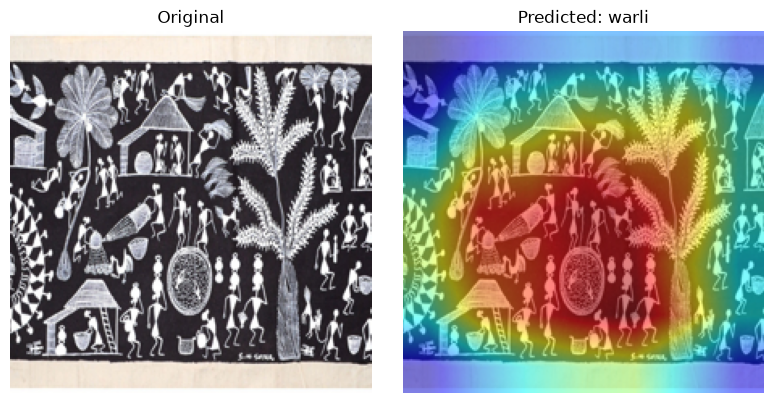

In [5]:
import os
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt

# Same normalization used during training
gradcam_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

def run_gradcam(img_path, model, target_layer, classes):
    img = Image.open(img_path).convert("RGB")
    img_resized = img.resize((224, 224))
    rgb_img = np.array(img_resized).astype(np.float32) / 255.0

    input_tensor = gradcam_transform(img).unsqueeze(0).to(device)

    cam = GradCAM(model=model, target_layers=[target_layer])
    pred_idx = model(input_tensor).argmax(dim=1).item()
    grayscale_cam = cam(input_tensor=input_tensor, targets=[ClassifierOutputTarget(pred_idx)])[0]

    visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(img_resized)
    axes[0].set_title("Original")
    axes[0].axis("off")
    axes[1].imshow(visualization)
    axes[1].set_title(f"Predicted: {classes[pred_idx]}")
    axes[1].axis("off")
    plt.tight_layout()
    plt.show()

# Pick a sample test image to try it on
test_img_path = "processed/style/test/warli/" + os.listdir("processed/style/test/warli")[0]
run_gradcam(test_img_path, style_model, style_model.layer4[-1], style_classes)

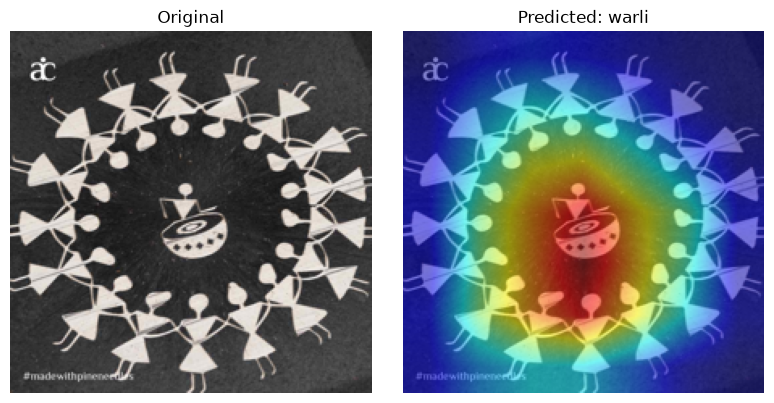

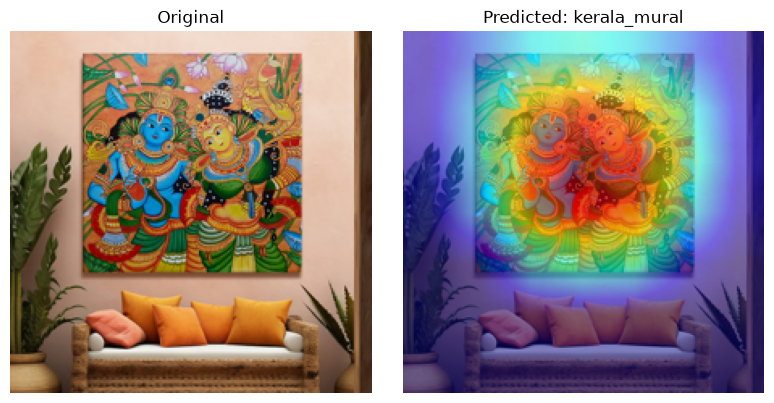

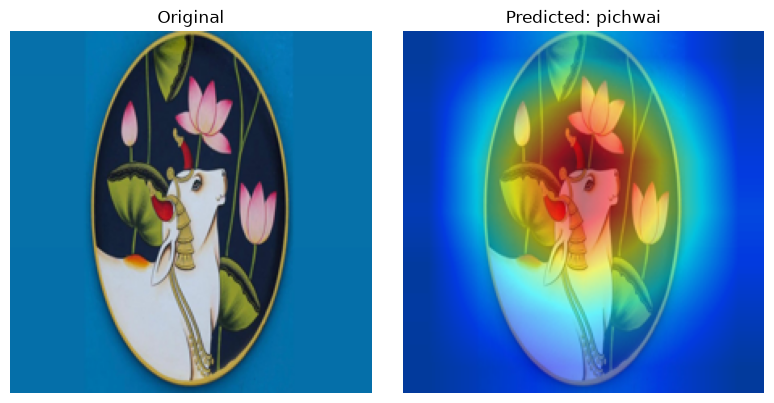

In [6]:
import random

test_dir = "processed/style/test"
sample_styles = random.sample(style_classes, 3)

for style in sample_styles:
    style_folder = os.path.join(test_dir, style)
    sample_img = os.path.join(style_folder, random.choice(os.listdir(style_folder)))
    run_gradcam(sample_img, style_model, style_model.layer4[-1], style_classes)

In [7]:
gradcam_code = '''
import numpy as np
from PIL import Image
from torchvision import transforms
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

gradcam_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

def generate_gradcam(img_path, model, target_layer, device):
    img = Image.open(img_path).convert("RGB")
    img_resized = img.resize((224, 224))
    rgb_img = np.array(img_resized).astype(np.float32) / 255.0

    input_tensor = gradcam_transform(img).unsqueeze(0).to(device)

    cam = GradCAM(model=model, target_layers=[target_layer])
    pred_idx = model(input_tensor).argmax(dim=1).item()
    grayscale_cam = cam(input_tensor=input_tensor, targets=[ClassifierOutputTarget(pred_idx)])[0]

    visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)
    return pred_idx, visualization
'''

os.makedirs("../backend", exist_ok=True)
with open("../backend/gradcam_utils.py", "w") as f:
    f.write(gradcam_code)

print("Grad-CAM utility saved to backend/gradcam_utils.py")

Grad-CAM utility saved to backend/gradcam_utils.py


In [8]:
import torch.nn as nn

# Create a version of the model that stops BEFORE the final classification layer
embedding_model = nn.Sequential(*list(style_model.children())[:-1])
embedding_model = embedding_model.to(device)
embedding_model.eval()

def get_embedding(img_path):
    img = Image.open(img_path).convert("RGB")
    input_tensor = gradcam_transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        embedding = embedding_model(input_tensor).squeeze().cpu().numpy()
    return embedding

# Quick test on one image
test_path = "processed/style/test/warli/" + os.listdir("processed/style/test/warli")[0]
emb = get_embedding(test_path)
print("Embedding shape:", emb.shape)
print("First 10 values:", emb[:10])

Embedding shape: (512,)
First 10 values: [0.         0.84034634 4.7461033  3.5125515  1.0517653  1.2524916
 0.         0.1458812  2.2003868  0.5680474 ]


In [9]:
import pickle

reference_dir = "processed/style/train"
embedding_db = []

for style in style_classes:
    style_folder = os.path.join(reference_dir, style)
    for fname in os.listdir(style_folder):
        img_path = os.path.join(style_folder, fname)
        emb = get_embedding(img_path)
        embedding_db.append({
            "path": img_path,
            "style": style,
            "embedding": emb
        })
    print(f"Processed {style}: {len(os.listdir(style_folder))} images")

with open("../models/embedding_db.pkl", "wb") as f:
    pickle.dump(embedding_db, f)

print(f"\nTotal embeddings stored: {len(embedding_db)}")

Processed gond: 68 images
Processed kalighat: 170 images
Processed kangra: 60 images
Processed kerala_mural: 65 images
Processed madhubani: 66 images
Processed mandana_art: 98 images
Processed pichwai: 67 images


D:\folk-art-ai\venv\Lib\site-packages\PIL\Image.py:1136: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Processed warli: 67 images

Total embeddings stored: 661


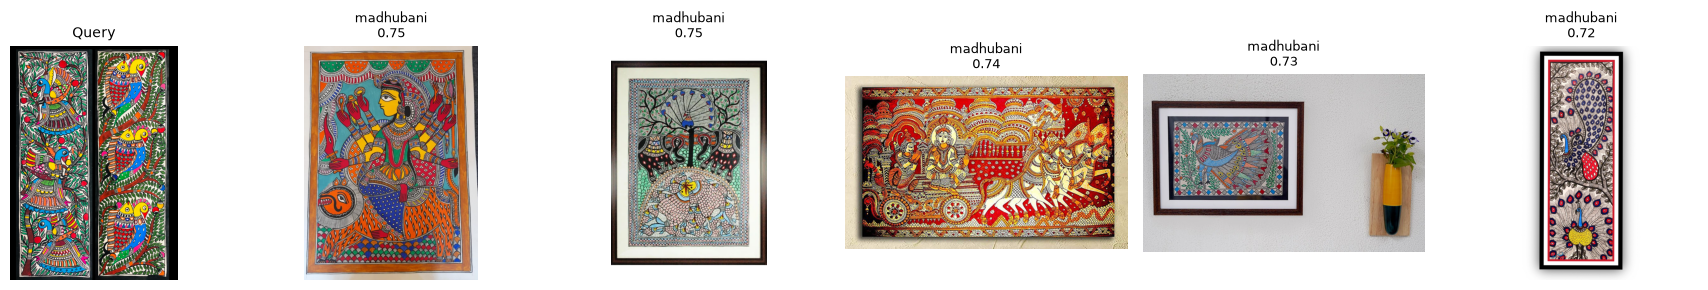

In [10]:
from sklearn.metrics.pairwise import cosine_similarity

def find_similar(query_img_path, embedding_db, top_k=5):
    query_emb = get_embedding(query_img_path).reshape(1, -1)

    db_embeddings = np.array([item["embedding"] for item in embedding_db])
    similarities = cosine_similarity(query_emb, db_embeddings)[0]

    top_indices = similarities.argsort()[::-1][:top_k]

    results = []
    for idx in top_indices:
        results.append({
            "path": embedding_db[idx]["path"],
            "style": embedding_db[idx]["style"],
            "similarity": similarities[idx]
        })
    return results

# Test on a sample query image
query_path = "processed/style/test/madhubani/" + os.listdir("processed/style/test/madhubani")[0]
results = find_similar(query_path, embedding_db, top_k=5)

# Display query + results
fig, axes = plt.subplots(1, 6, figsize=(18, 3))
axes[0].imshow(Image.open(query_path))
axes[0].set_title("Query", fontsize=10)
axes[0].axis("off")

for i, res in enumerate(results):
    axes[i+1].imshow(Image.open(res["path"]))
    axes[i+1].set_title(f"{res['style']}\n{res['similarity']:.2f}", fontsize=9)
    axes[i+1].axis("off")

plt.tight_layout()
plt.show()

In [11]:
similarity_code = '''
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

def find_similar(query_embedding, embedding_db, top_k=5):
    query_emb = query_embedding.reshape(1, -1)
    db_embeddings = np.array([item["embedding"] for item in embedding_db])
    similarities = cosine_similarity(query_emb, db_embeddings)[0]

    top_indices = similarities.argsort()[::-1][:top_k]

    results = []
    for idx in top_indices:
        results.append({
            "path": embedding_db[idx]["path"],
            "style": embedding_db[idx]["style"],
            "similarity": float(similarities[idx])
        })
    return results
'''

with open("../backend/similarity_utils.py", "w") as f:
    f.write(similarity_code)

print("Similarity search utility saved to backend/similarity_utils.py")

Similarity search utility saved to backend/similarity_utils.py


In [12]:
cultural_data = {
    "warli": {
        "state": "Maharashtra",
        "region": "Palghar, Thane, Nashik districts",
        "history": "One of the oldest tribal art forms in India, practiced by the Warli tribe for centuries, traditionally painted on mud walls using rice paste.",
        "symbolism": "Depicts daily life, nature, and rituals using basic geometric shapes — circles, triangles, and lines representing the sun, mountains, and human figures."
    },
    "madhubani": {
        "state": "Bihar",
        "region": "Mithila region",
        "history": "Also known as Mithila painting, traditionally created by women on freshly plastered mud walls and floors, dating back centuries.",
        "symbolism": "Features intricate patterns, natural motifs, and mythological themes, often depicting Hindu deities and nature."
    },
    "pichwai": {
        "state": "Rajasthan",
        "region": "Nathdwara",
        "history": "Traditionally painted on cloth and hung behind the idol of Lord Krishna (Shrinathji) in temples.",
        "symbolism": "Rich, detailed depictions of Krishna's life, often featuring cows, lotus flowers, and elaborate festival scenes."
    },
    "kalighat": {
        "state": "West Bengal",
        "region": "Kolkata (near Kalighat temple)",
        "history": "Emerged in the 19th century near the Kalighat temple, evolving from religious scroll painting into bold, satirical social commentary.",
        "symbolism": "Characterized by bold, sweeping brushstrokes and flat colors, depicting deities as well as social and political themes."
    },
    "kangra": {
        "state": "Himachal Pradesh",
        "region": "Kangra Valley",
        "history": "Flourished in the 18th century under the patronage of the Kangra royal court, part of the broader Pahari painting tradition.",
        "symbolism": "Delicate, lyrical style often depicting romantic and devotional themes, especially stories of Radha and Krishna."
    },
    "kerala_mural": {
        "state": "Kerala",
        "region": "Statewide, especially temple towns",
        "history": "An ancient temple art form found on the walls of temples and palaces across Kerala, dating back over a thousand years.",
        "symbolism": "Vivid, elaborate depictions of Hindu mythology using a distinct palette of earthy reds, yellows, greens, and blacks."
    },
    "mandana_art": {
        "state": "Rajasthan",
        "region": "Shekhawati and rural Rajasthan",
        "history": "Traditionally drawn on floors and walls of homes during festivals and special occasions using red ochre and white chalk.",
        "symbolism": "Geometric and floral patterns believed to bring good fortune, often drawn fresh for weddings and religious ceremonies."
    },
    "gond": {
        "state": "Madhya Pradesh",
        "region": "Gondwana region",
        "history": "Practiced by the Gond tribe, one of India's largest tribal communities, traditionally painted on walls and floors.",
        "symbolism": "Dense, dotted patterns depicting nature, animals, and folklore, believed to bring good luck when displayed in homes."
    },
}

with open("../models/cultural_data.json", "w") as f:
    json.dump(cultural_data, f, indent=2)

print("Cultural data saved for all", len(cultural_data), "styles.")

Cultural data saved for all 8 styles.


In [13]:
# Approximate coordinates for each region (for the map visual later)
region_coords = {
    "warli": {"lat": 19.6, "lon": 73.0},
    "madhubani": {"lat": 26.4, "lon": 86.1},
    "pichwai": {"lat": 24.9, "lon": 73.8},
    "kalighat": {"lat": 22.5, "lon": 88.3},
    "kangra": {"lat": 32.1, "lon": 76.3},
    "kerala_mural": {"lat": 10.5, "lon": 76.2},
    "mandana_art": {"lat": 27.6, "lon": 75.1},
    "gond": {"lat": 22.0, "lon": 80.5},
}

def generate_writeup(style_name, cultural_data, region_coords):
    data = cultural_data[style_name]
    writeup = {
        "style": style_name.replace("_", " ").title(),
        "state": data["state"],
        "region": data["region"],
        "history": data["history"],
        "symbolism": data["symbolism"],
        "coordinates": region_coords[style_name],
        "summary": f"{style_name.replace('_', ' ').title()} is a folk art tradition from {data['region']}, {data['state']}. {data['history']}"
    }
    return writeup

# Test it
test_writeup = generate_writeup("madhubani", cultural_data, region_coords)
for k, v in test_writeup.items():
    print(f"{k}: {v}")

style: Madhubani
state: Bihar
region: Mithila region
history: Also known as Mithila painting, traditionally created by women on freshly plastered mud walls and floors, dating back centuries.
symbolism: Features intricate patterns, natural motifs, and mythological themes, often depicting Hindu deities and nature.
coordinates: {'lat': 26.4, 'lon': 86.1}
summary: Madhubani is a folk art tradition from Mithila region, Bihar. Also known as Mithila painting, traditionally created by women on freshly plastered mud walls and floors, dating back centuries.


In [14]:
cultural_code = '''
import json

def load_cultural_data(path="../models/cultural_data.json"):
    with open(path) as f:
        return json.load(f)

region_coords = {
    "warli": {"lat": 19.6, "lon": 73.0},
    "madhubani": {"lat": 26.4, "lon": 86.1},
    "pichwai": {"lat": 24.9, "lon": 73.8},
    "kalighat": {"lat": 22.5, "lon": 88.3},
    "kangra": {"lat": 32.1, "lon": 76.3},
    "kerala_mural": {"lat": 10.5, "lon": 76.2},
    "mandana_art": {"lat": 27.6, "lon": 75.1},
    "gond": {"lat": 22.0, "lon": 80.5},
}

def generate_writeup(style_name, cultural_data):
    data = cultural_data[style_name]
    return {
        "style": style_name.replace("_", " ").title(),
        "state": data["state"],
        "region": data["region"],
        "history": data["history"],
        "symbolism": data["symbolism"],
        "coordinates": region_coords[style_name],
        "summary": f"{style_name.replace(\\'_\\', \\' \\').title()} is a folk art tradition from {data[\\'region\\']}, {data[\\'state\\']}. {data[\\'history\\']}"
    }
'''

with open("../backend/cultural_utils.py", "w") as f:
    f.write(cultural_code)

print("Cultural context utility saved to backend/cultural_utils.py")

Cultural context utility saved to backend/cultural_utils.py
